# 02 · Nettoyage Avancé des Données
## CEET Smart Grid – Energy Blackout Prediction
**Objectif :** Nettoyer, imputer et enrichir le dataset pour le pipeline ML.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from data_preprocessing import (
    load_raw, clean_basic, handle_missing,
    handle_outliers, add_temporal_features,
    add_energy_features, encode_categoricals,
    run_preprocessing_pipeline
)
from utils import DATA_RAW, DATA_PROC, detect_outliers_iqr

pd.set_option('display.max_columns', 30)

### 2.1 Chargement et Nettoyage de Base

In [2]:
df_raw = load_raw()
print(f"Brut : {df_raw.shape}")
df = clean_basic(df_raw)
print(f"Après clean_basic : {df.shape}")
print(f"Doublons supprimés : {df_raw.shape[0] - df.shape[0]}")

2026-06-12 11:03:41 | INFO     | preprocessing | Chargement depuis D:\Data_Science_Lab\Data_Project_Capstone_IBM\energy-grid-blackout-prediction\data\raw\ceet_togo_smartgrid_dataset.csv
2026-06-12 11:03:41 | INFO     | preprocessing | Dataset chargé : 50,000 lignes × 25 colonnes
2026-06-12 11:03:41 | INFO     | preprocessing | Nettoyage de base...
2026-06-12 11:03:41 | INFO     | preprocessing |   Nettoyage de base terminé


Brut : (50000, 25)
Après clean_basic : (50000, 25)
Doublons supprimés : 0


### 2.2 Traitement des Valeurs Manquantes

In [3]:
print("Avant imputation :")
print(df.isnull().sum()[df.isnull().sum() > 0])
df = handle_missing(df)
print("\nAprès imputation :")
print(df.isnull().sum()[df.isnull().sum() > 0])
print("\n Aucune valeur manquante restante" if df.isnull().sum().sum() == 0 else "⚠️ Valeurs manquantes restantes")

2026-06-12 11:03:46 | INFO     | preprocessing | Traitement des valeurs manquantes...


2026-06-12 11:03:46 | INFO     | preprocessing |   Valeurs nulles restantes : 0


Avant imputation :
Series([], dtype: int64)

Après imputation :
Series([], dtype: int64)

 Aucune valeur manquante restante


### 2.3 Détection et Traitement des Outliers

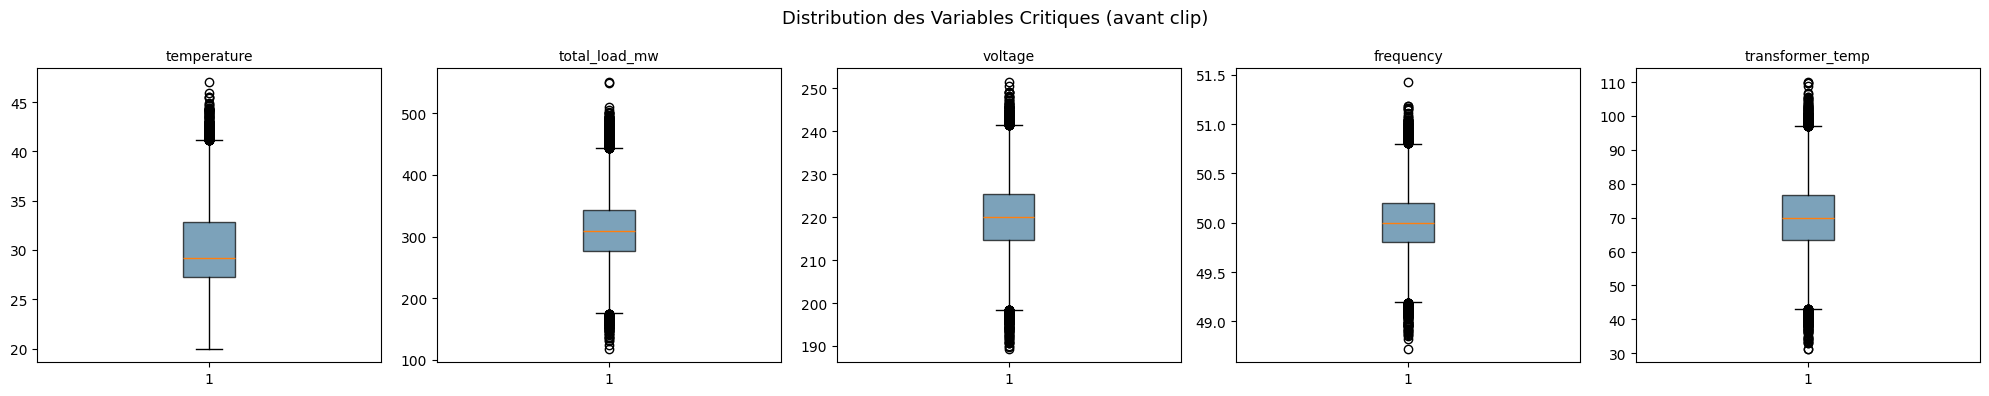

2026-06-12 11:03:51 | INFO     | preprocessing | Traitement des outliers (stratégie: clip)...
2026-06-12 11:03:51 | INFO     | preprocessing |   temperature: 309 outliers traités
2026-06-12 11:03:51 | INFO     | preprocessing |   total_load_mw: 489 outliers traités
2026-06-12 11:03:51 | INFO     | preprocessing |   available_power_mw: 340 outliers traités
2026-06-12 11:03:51 | INFO     | preprocessing |   voltage: 357 outliers traités
2026-06-12 11:03:51 | INFO     | preprocessing |   frequency: 335 outliers traités
2026-06-12 11:03:52 | INFO     | preprocessing |   transformer_temp: 323 outliers traités
2026-06-12 11:03:52 | INFO     | preprocessing |   outage_risk: 1742 outliers traités


 Outliers traités (clip)


In [4]:
critical_cols = ['temperature', 'total_load_mw', 'voltage', 'frequency', 'transformer_temp']

fig, axes = plt.subplots(1, len(critical_cols), figsize=(20, 4))
fig.suptitle("Distribution des Variables Critiques (avant clip)", fontsize=13)
for ax, col in zip(axes, critical_cols):
    ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
               boxprops=dict(facecolor='#457B9D', alpha=0.7))
    ax.set_title(col, fontsize=10)
plt.tight_layout()
plt.show()

df = handle_outliers(df, strategy='clip')
print(" Outliers traités (clip)")

### 2.4 Feature Engineering Temporel

In [5]:
df = add_temporal_features(df)
new_cols = ['year','month','day','day_of_week','is_weekend','is_peak_hour',
            'hour_sin','hour_cos','month_sin','month_cos','time_of_day']
print("Nouvelles colonnes temporelles :")
print(df[new_cols].head(3))

2026-06-12 11:03:56 | INFO     | preprocessing | Ajout des features temporelles...
2026-06-12 11:03:56 | INFO     | preprocessing |   Features temporelles ajoutées


Nouvelles colonnes temporelles :
   year  month  day  day_of_week  is_weekend  is_peak_hour  hour_sin  \
0  2020      1    1            2           0             0  0.000000   
1  2020      1    1            2           0             0  0.258819   
2  2020      1    1            2           0             0  0.500000   

   hour_cos  month_sin  month_cos time_of_day  
0  1.000000        0.5   0.866025        Nuit  
1  0.965926        0.5   0.866025        Nuit  
2  0.866025        0.5   0.866025        Nuit  


### 2.5 Features Énergétiques Dérivées

In [6]:
df = add_energy_features(df)
energy_feats = ['load_ratio','power_margin','power_margin_pct','grid_stress_index',
                'voltage_deviation','renewable_share','industrial_share']
print("Features énergétiques :")
print(df[energy_feats].describe().round(3))

2026-06-12 11:04:01 | INFO     | preprocessing | Ajout des features énergétiques...
2026-06-12 11:04:01 | INFO     | preprocessing |   Features énergétiques ajoutées


Features énergétiques :
       load_ratio  power_margin  power_margin_pct  grid_stress_index  \
count   50000.000     50000.000         50000.000          50000.000   
mean        1.201       -50.311           -20.071              0.750   
std         0.218        54.469            21.814              0.100   
min         0.436      -301.840          -144.293              0.396   
25%         1.050       -85.620           -33.764              0.681   
50%         1.187       -48.715           -18.741              0.745   
75%         1.338       -13.298            -5.018              0.814   
max         2.443       153.350            56.383              1.192   

       voltage_deviation  renewable_share  industrial_share  
count          50000.000        50000.000         50000.000  
mean               6.357            8.724             0.386  
std                4.798            3.989             0.072  
min                0.000            1.635             0.013  
25%              

### 2.6 Encodage des Variables Catégorielles

In [7]:
df, encoders = encode_categoricals(df)
print("Encodeurs créés :")
for col, enc in encoders.items():
    print(f"  {col}: {list(enc.classes_)}")

2026-06-12 11:04:06 | INFO     | preprocessing | Encodage des variables catégorielles...
2026-06-12 11:04:06 | INFO     | preprocessing |   region: 6 classes
2026-06-12 11:04:06 | INFO     | preprocessing |   city: 7 classes
2026-06-12 11:04:06 | INFO     | preprocessing |   season: 2 classes
2026-06-12 11:04:06 | INFO     | preprocessing |   event: 5 classes
2026-06-12 11:04:06 | INFO     | preprocessing |   time_of_day: 5 classes


Encodeurs créés :
  region: ['Centrale', 'Kara', 'Lome', 'Maritime', 'Plateaux', 'Savanes']
  city: ['Atakpame', 'Dapaong', 'Kara', 'Kpalime', 'Lome', 'Sokode', 'Tsevie']
  season: ['Pluvieuse', 'Seche']
  event: ['Concert', 'Event Politique', 'Festivale', 'Match de Football', 'Pas evenement']
  time_of_day: ['Après-midi', 'Matin', 'Nuit', 'Nuit tardive', 'Soir']


### 2.7 Sauvegarde du Dataset Traité

In [8]:
# Remplir les NaN des lags/rolling
num_cols = df.select_dtypes(include=np.number).columns
df[num_cols] = df[num_cols].fillna(method='bfill').fillna(0)

out = DATA_PROC / 'ceet_processed.csv'
df.to_csv(out, index=False)
print(f" Dataset sauvegardé : {out}")
print(f"   Shape final : {df.shape}")
print(f"   Colonnes    : {df.shape[1]}")
print(f"\n=== RÉSUMÉ ===")
print(f"  Blackouts    : {df['blackout'].sum():,} ({df['blackout'].mean()*100:.2f}%)")
print(f"  Surcharges   : {df['overload'].sum():,} ({df['overload'].mean()*100:.2f}%)")
print(f"  Risque moyen : {df['outage_risk'].mean():.1f}%")

C:\Users\HP\AppData\Local\Temp\ipykernel_11140\201666097.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df[num_cols] = df[num_cols].fillna(method='bfill').fillna(0)


 Dataset sauvegardé : D:\Data_Science_Lab\Data_Project_Capstone_IBM\energy-grid-blackout-prediction\data\processed\ceet_processed.csv
   Shape final : (50000, 75)
   Colonnes    : 75

=== RÉSUMÉ ===
  Blackouts    : 1,975 (3.95%)
  Surcharges   : 41,234 (82.47%)
  Risque moyen : 94.6%
